<a href="https://colab.research.google.com/github/gaurizendekar/Data_Science_labs/blob/main/Exp10_Unsupervised_Generative_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment 10: Unsupervised Generative Models

Aim: To implement an Unsupervised Generative Model using Autoencoder in TensorFlow and Keras.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7888 - loss: 0.2262 - val_accuracy: 0.8046 - val_loss: 0.1451
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8097 - loss: 0.1271 - val_accuracy: 0.8109 - val_loss: 0.1125
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8125 - loss: 0.1085 - val_accuracy: 0.8122 - val_loss: 0.1023
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8134 - loss: 0.1008 - val_accuracy: 0.8126 - val_loss: 0.0969
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8138 - loss: 0.0961 - val_accuracy: 0.8130 - val_loss: 0.0929
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8142 - loss: 0.0924 - val_accuracy: 0.8134 - val_loss: 0.0897
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8144 - loss: 0.0898 - val_accuracy: 0.8135 - val_loss: 0.0876
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8145 - loss: 0.0879 - val_accu

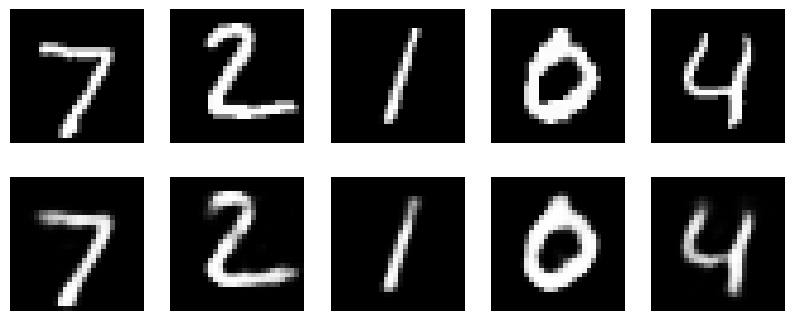

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Reshape

# Load MNIST Dataset
(X_train, _), (X_test, _) = mnist.load_data()

# Normalize Dataset
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape Dataset
X_train = X_train.reshape(
    (len(X_train), 28, 28, 1)
)

X_test = X_test.reshape(
    (len(X_test), 28, 28, 1)
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# Encoder
encoder_input = Input(shape=(28, 28, 1))

x = Flatten()(encoder_input)

x = Dense(
    128,
    activation='relu'
)(x)

encoded = Dense(
    64,
    activation='relu'
)(x)

# Decoder
x = Dense(
    128,
    activation='relu'
)(encoded)

x = Dense(
    28 * 28,
    activation='sigmoid'
)(x)

decoded = Reshape((28, 28, 1))(x)

# Autoencoder Model
autoencoder = Model(
    encoder_input,
    decoded
)

# Model Summary
autoencoder.summary()

# Compile Model
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=10,
    batch_size=256,
    validation_data=(X_test, X_test)
)

# Evaluate Model
loss, accuracy = autoencoder.evaluate(
    X_test,
    X_test
)

print("\nTest Loss :", loss)
print("Test Accuracy :", accuracy)

# Generate Reconstructed Images
decoded_images = autoencoder.predict(
    X_test[:5]
)

# Display Original and Reconstructed Images
plt.figure(figsize=(10,4))

for i in range(5):

    # Original Image
    plt.subplot(2,5,i+1)
    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )
    plt.axis('off')

    # Reconstructed Image
    plt.subplot(2,5,i+6)
    plt.imshow(
        decoded_images[i].reshape(28,28),
        cmap='gray'
    )
    plt.axis('off')

plt.show()

Conclusion: Successfully implemented an unsupervised generative model using Autoencoder architecture in TensorFlow and Keras for image reconstruction.